# Aprendizaje Automatico I

## Analisis Exploratorio de Datos (EDA)

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:** Alejandro Acosta, Diego Huaret, Gastón Rinaldi, Agustín Torres

---

### Contenidos

1. Configuracion del entorno y carga de datos
2. Inspeccion estructural del dataset
3. Analisis descriptivo: tendencia central, dispersion, sesgo y curtosis
4. Gestion de datos: nulos, duplicados y tipos
5. Analisis de distribucion y pruebas de normalidad
6. Analisis de balanceo de clases
7. Correlaciones: Pearson, Spearman y colinealidad
8. Deteccion y tratamiento de outliers (IQR y Z-score)
9. Conclusiones y proximos pasos

---

## 1. Configuracion del Entorno

Importamos las librerias necesarias y configuramos los parametros globales de visualizacion. Se utiliza un estilo consistente para garantizar la reproducibilidad visual del analisis.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.5
numpy: 2.5.2


---

## 2. Carga e Inspeccion Estructural del Dataset

Diccionario de variables:

| Variable | Descripción |
|---|---|
| CRIM | Tasa de criminalidad per cápita por localidad |
| ZN | % de suelo residencial en lotes grandes |
| INDUS | % de acres de negocio no minorista por localidad |
| CHAS | Variable dummy (1 si limita con el río Charles, 0 si no) |
| NOX | Concentración de óxidos de nitrógeno |
| RM | Promedio de habitaciones por vivienda |
| AGE | % de viviendas ocupadas por el propietario construidas antes de 1940 |
| DIS | Distancia ponderada a 5 centros de empleo de Boston |
| RAD | Índice de accesibilidad a autopistas radiales |
| TAX | Tasa de impuesto a la propiedad por cada $10.000 |
| PTRATIO | Ratio alumno-profesor por localidad |
| B | 1000(Bk - 0.63)^2, donde Bk es la proporción de población afroamericana |
| LSTAT | % de población de estatus socioeconómico bajo |
| MEDV | **Variable objetivo**: valor medio de la vivienda (en miles de USD) |


In [36]:
df = pd.read_csv('../data/house-prices-tp.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(10)

Dimensiones del dataset: 556 filas x 14 columnas
Memoria utilizada: 0.06 MB



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
5,0.0626,0.0000,11.9300,0.0000,0.5730,6.5930,69.1000,2.4786,1.0000,273.0000,21.0000,391.9900,9.6700,22.4000
6,0.3581,0.0000,6.2000,1.0000,0.5070,6.9510,88.5000,2.8617,8.0000,307.0000,17.4000,391.7000,9.7100,26.7000
7,0.0883,0.0000,10.8100,0.0000,0.4130,6.4170,6.6000,5.2873,4.0000,305.0000,19.2000,383.7300,6.7200,24.2000
8,1.3547,0.0000,8.1400,0.0000,0.5380,6.0720,100.0000,4.1750,4.0000,307.0000,21.0000,376.7300,13.0400,14.5000
9,0.3035,0.0000,7.3800,0.0000,0.4930,6.3120,28.9000,5.4159,5.0000,287.0000,19.6000,396.9000,6.1500,23.0000


In [37]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 50)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [38]:
#Cambio de tipo de dato a variable CHAS a tipo categórica
df['CHAS'] = df['CHAS'].astype('category')

In [39]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (13): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categoricas (1): ['CHAS']


---

## 3. Analisis Descriptivo

### 3.1 Medidas de Tendencia Central y Dispersion

Las medidas de tendencia central resumen la ubicacion tipica de los datos:

- **Media aritmetica:** $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$

- **Mediana:** Valor que divide la distribucion en dos mitades iguales. Robusta ante outliers.

- **Moda:** Valor de mayor frecuencia.

Las medidas de dispersion cuantifican la variabilidad:

- **Varianza muestral:** $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$

- **Desviacion estandar:** $s = \sqrt{s^2}$

- **Coeficiente de variacion (CV):** $CV = \frac{s}{\bar{x}} \times 100\%$ -- util para comparar dispersiones entre variables con distintas escalas.

### 3.2 Sesgo (Skewness) y Curtosis (Kurtosis)

El **sesgo** (tercer momento estandarizado) mide la asimetria de la distribucion:

$$\gamma_1 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

- $\gamma_1 = 0$: distribucion simetrica.
- $\gamma_1 > 0$: sesgo positivo (cola derecha mas larga).
- $\gamma_1 < 0$: sesgo negativo (cola izquierda mas larga).

La **curtosis en exceso** (cuarto momento estandarizado, ajustado) mide el peso de las colas:

$$\kappa = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

- $\kappa = 0$: mesocurtica (similar a la normal).
- $\kappa > 0$: leptocurtica (colas pesadas, pico mas pronunciado).
- $\kappa < 0$: platicurtica (colas livianas, distribucion mas aplanada).

In [40]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.8455,0.3153,13.8286,236.5681,0.0063,0.0845,0.3153,4.8714,88.9762,3.7467,15.2487
ZN,13.1972,0.0000,24.9030,188.6993,0.0000,0.0000,0.0000,20.0000,100.0000,1.9578,2.7498
INDUS,11.2187,9.6900,6.9420,61.8789,0.4600,5.1300,9.6900,18.1000,27.7400,0.3015,-1.2064
NOX,0.5600,0.5380,0.1195,21.3325,0.3850,0.4530,0.5380,0.6440,0.8710,0.6944,-0.2296
RM,6.2918,6.2080,0.7824,12.4352,3.5610,5.8755,6.2080,6.6385,8.7800,0.3738,1.5551
AGE,67.6323,76.5000,28.4619,42.0833,2.9000,42.2750,76.5000,93.8250,100.0000,-0.5507,-1.0382
DIS,3.9441,3.3401,2.2557,57.1914,1.1296,2.1121,3.3401,5.4007,12.1265,1.0789,0.7054
RAD,9.6994,5.0000,8.6845,89.5366,1.0000,4.0000,5.0000,23.6327,24.0000,0.9515,-0.9478
TAX,409.5751,335.0000,167.6894,40.9423,187.0000,279.0000,335.0000,666.0000,711.0000,0.6323,-1.1705
PTRATIO,18.4299,19.0000,2.1948,11.9087,12.6000,17.0000,19.0000,20.2000,22.0000,-0.7872,-0.3048


In [41]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.4f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
      CRIM: sesgo=+3.7467 [sesgo positivo (alto)], curtosis=+15.249 [leptocurtica (colas pesadas)]
        ZN: sesgo=+1.9578 [sesgo positivo (alto)], curtosis=+2.750 [leptocurtica (colas pesadas)]
     INDUS: sesgo=+0.3015 [aproximadamente simetrica], curtosis=-1.206 [platicurtica (colas livianas)]
       NOX: sesgo=+0.6944 [sesgo positivo (moderado)], curtosis=-0.230 [mesocurtica]
        RM: sesgo=+0.3738 [aproximadamente simetrica], curtosis=+1.555 [leptocurtica (colas pesadas)]
       AGE: sesgo=-0.5507 [sesgo negativo (moderado)], curtosis=-1.038 [platicurtica (colas livianas)]
       DIS: sesgo=+1.0789 [sesgo positivo (alto)], curtosis=+0.705 [leptocurtica (colas pesadas)]
       RAD: sesgo=+0.9515 [sesgo positivo (moderado)], curtosis=-0.948 [platicurtica (colas livianas)]
       TAX: sesgo=+0.6323 [sesgo positivo (moderado)], curtosis=-1.171 [platicurtica (colas livianas)]
   PTRATIO: sesgo=-0.7872 [sesgo negativo (moderado)], curtosis=-0.30

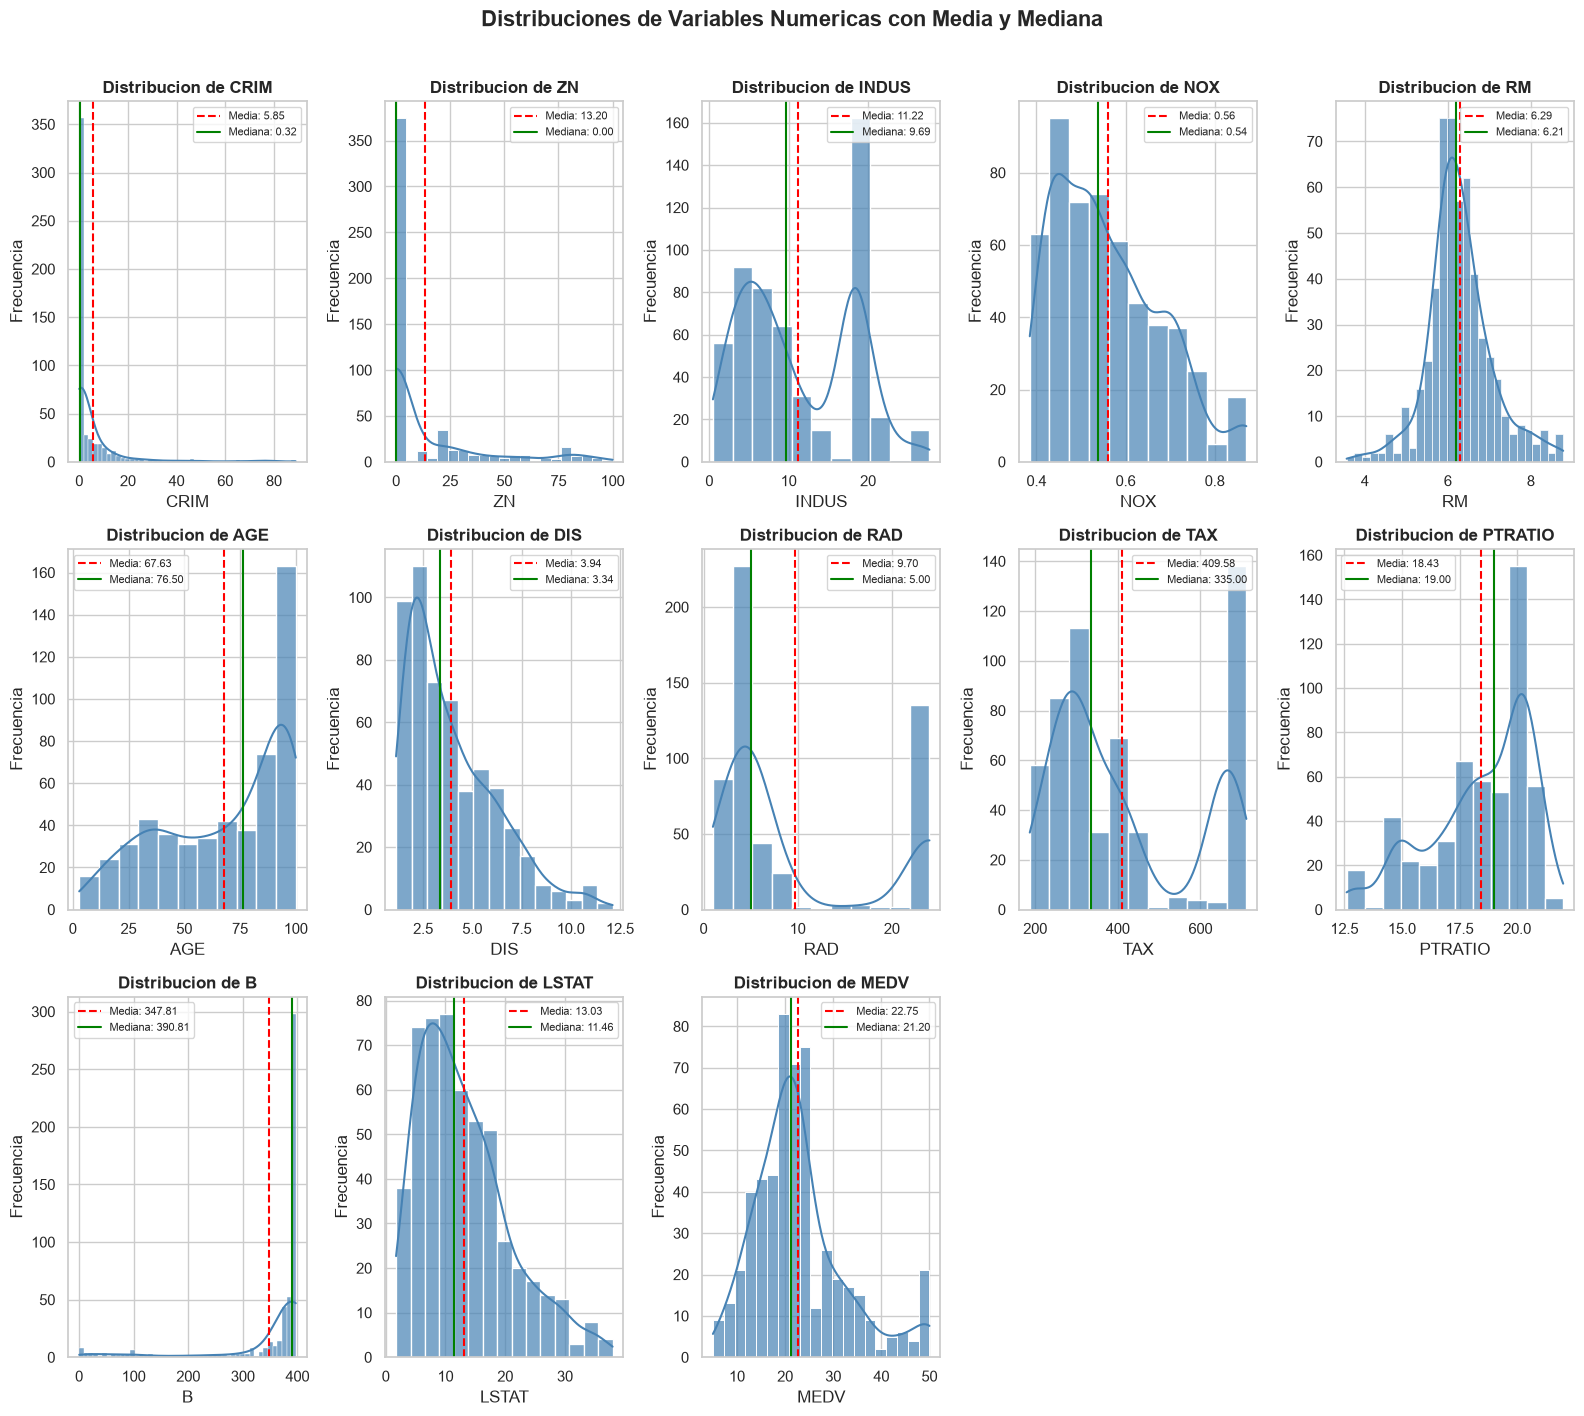

In [42]:
fig, axes = plt.subplots(3, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [43]:
cols_categoricas

['CHAS']

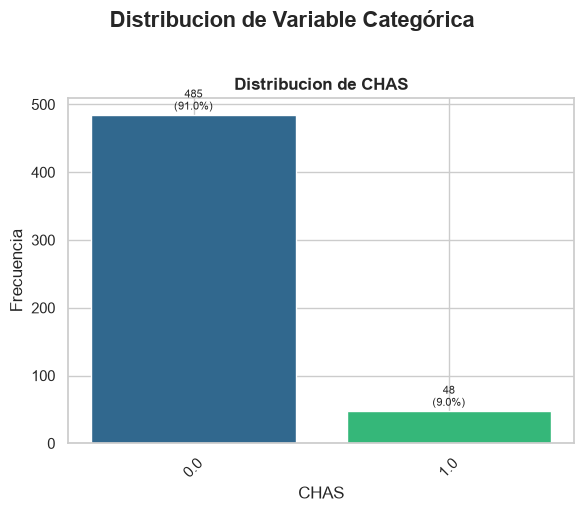

In [44]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

for i, col in enumerate(cols_categoricas):
    conteo = df[col].value_counts()
    ax = axes # Changed from ax = axes[i]
    bars = ax.bar(conteo.index.astype(str), conteo.values,
                  color=sns.color_palette('viridis', len(conteo)),
                  edgecolor='white')

    # Etiquetas con porcentaje
    total = conteo.sum()
    for bar, val in zip(bars, conteo.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribucion de Variable Categórica',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Gestion de Datos: Nulos, Duplicados y Consistencia

### 4.1 Patrones de Datos Faltantes

Existen tres mecanismos de datos faltantes (Rubin, 1976):

1. **MCAR** (Missing Completely At Random): La probabilidad de que un dato falte no depende de ninguna variable. $P(R | Y_{obs}, Y_{mis}) = P(R)$

2. **MAR** (Missing At Random): La probabilidad depende de datos observados pero no de los faltantes. $P(R | Y_{obs}, Y_{mis}) = P(R | Y_{obs})$

3. **MNAR** (Missing Not At Random): La probabilidad depende del propio valor faltante.

Identificar el patron es crucial para elegir la estrategia de imputacion adecuada (eliminacion, imputacion por media/mediana, KNN, MICE, etc.).

### 4.2 Registros Duplicados

Los duplicados pueden introducir sesgo en las estimaciones estadisticas al sobre-representar ciertos patrones. En datasets transaccionales como `diamonds`, duplicados exactos pueden ser registros legitimos (dos diamantes identicos) o errores de carga.

In [45]:
df.isnull().sum()

CRIM       23
ZN         22
INDUS      15
CHAS       23
NOX        24
RM         21
AGE        24
DIS        15
RAD        28
TAX        18
PTRATIO    28
B          22
LSTAT      22
MEDV       21
dtype: int64

In [46]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)      Tipo
CRIM        23          4.1367   float64
ZN          22          3.9568   float64
INDUS       15          2.6978   float64
CHAS        23          4.1367  category
NOX         24          4.3165   float64
RM          21          3.7770   float64
AGE         24          4.3165   float64
DIS         15          2.6978   float64
RAD         28          5.0360   float64
TAX         18          3.2374   float64
PTRATIO     28          5.0360   float64
B           22          3.9568   float64
LSTAT       22          3.9568   float64
MEDV        21          3.7770   float64

Total de celdas con nulos: 306 (3.9311% del dataset)


In [47]:
print("Cantidad de registros antes de la eliminacion de nulos: ", df.shape[0])
df = df.drop_duplicates()
print("Cantidad de registros antes de la eliminacion de nulos: ", df.shape[0])

Cantidad de registros antes de la eliminacion de nulos:  556
Cantidad de registros antes de la eliminacion de nulos:  556


In [48]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: en un dataset de productos fisicos, es plausible que\n'
          'dos diamantes distintos compartan todas sus caracteristicas medidas.\n'
          'Eliminarlos introduciria sesgo por sub-representacion.')

Registros duplicados: 0 (0.00%)



---

## 5. Pruebas de Normalidad

### 5.1 Fundamento Teorico

Muchos metodos estadisticos asumen normalidad en los datos. Evaluar esta hipotesis es un paso critico del EDA.

#### Test de Shapiro-Wilk

Contrasta la hipotesis nula $H_0$: la muestra proviene de una distribucion normal.

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

donde $x_{(i)}$ son los estadisticos de orden y $a_i$ son constantes tabuladas.

**Limitacion:** Shapiro-Wilk tiene un limite de $n \leq 5000$ en `scipy`. Para datasets grandes, se usa una muestra aleatoria o el test de **D'Agostino-Pearson**.

#### Test de D'Agostino-Pearson

Combina el test de sesgo ($Z_1$) y el test de curtosis ($Z_2$) en un estadistico $K^2$:

$$K^2 = Z_1^2 + Z_2^2 \sim \chi^2(2)$$

Es mas adecuado para muestras grandes ($n > 20$).

**Criterio de decision:** Si $p < \alpha$ (tipicamente $\alpha = 0.05$), se rechaza $H_0$ y se concluye que los datos no siguen una distribucion normal.

In [49]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4694,0.0000,438.7814,0.0000,No
1,ZN,0.5977,0.0000,198.8057,0.0000,No
2,INDUS,0.9085,0.0000,374.1978,0.0000,No
3,NOX,0.9373,0.0000,37.5234,0.0000,No
4,RM,0.9601,0.0000,32.6767,0.0000,No
5,AGE,0.8959,0.0000,155.4211,0.0000,No
6,DIS,0.8987,0.0000,81.2382,0.0000,No
7,RAD,0.6976,0.0000,143.1121,0.0000,No
8,TAX,0.8280,0.0000,314.9345,0.0000,No
9,PTRATIO,0.9076,0.0000,46.9050,0.0000,No


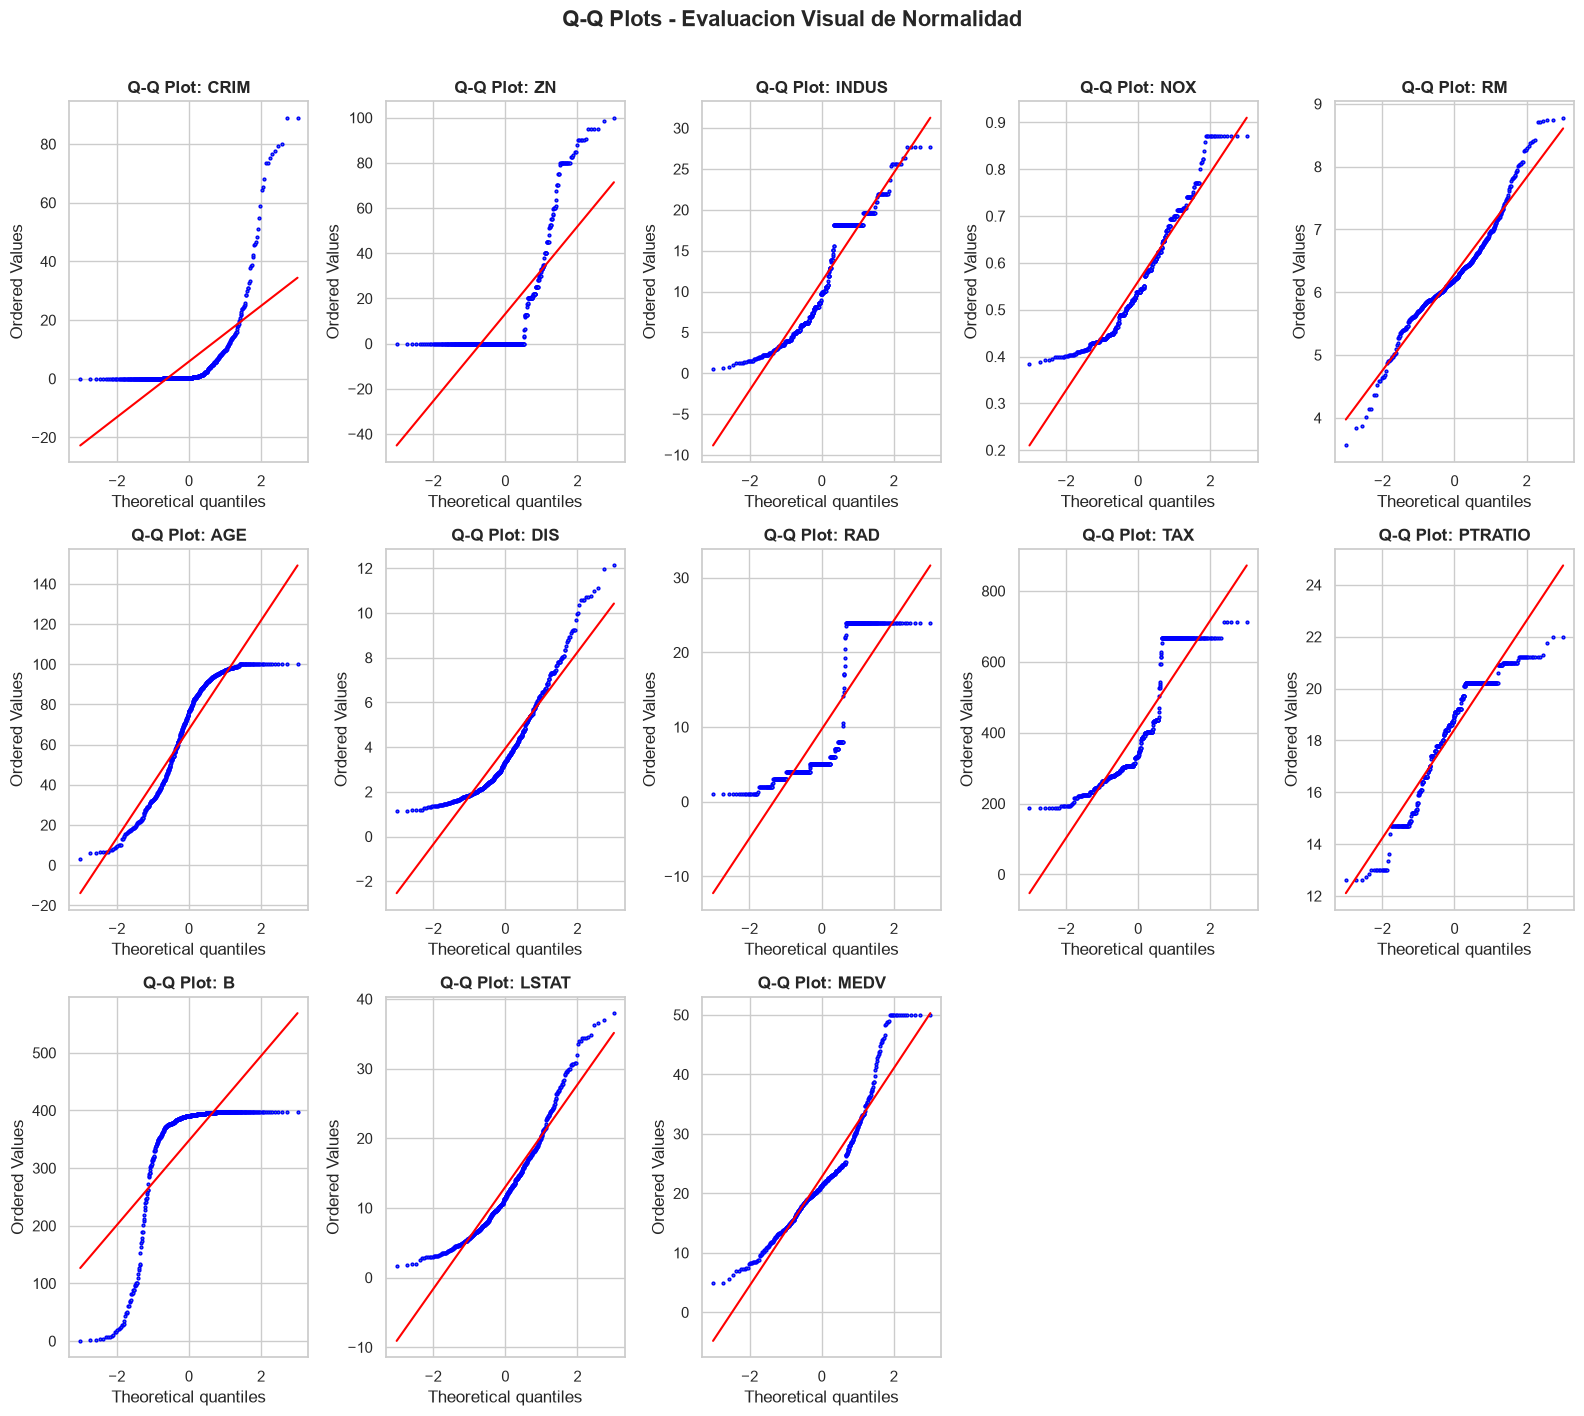

In [50]:
fig, axes = plt.subplots(3, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluacion Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 6. Analisis de Balanceo de Clases

### 6.1 Fundamento Teorico

En problemas de clasificacion, un desbalanceo severo entre clases puede sesgar al modelo hacia la clase mayoritaria. Se considera:

- **Balanceado:** La clase minoritaria tiene al menos el 40% de las observaciones de la clase mayoritaria.
- **Moderadamente desbalanceado:** Entre 20% y 40%.
- **Altamente desbalanceado:** Menos del 20%.

Una metrica util es el **Imbalance Ratio (IR)**:

$$IR = \frac{n_{\text{clase mayoritaria}}}{n_{\text{clase minoritaria}}}$$

Si $IR > 5$, se recomienda aplicar tecnicas de re-balanceo (oversampling con SMOTE, undersampling, o ajuste de pesos en el modelo).

Analizamos las variables categoricas `cut`, `color` y `clarity` como posibles targets de clasificacion.

In [51]:
for col in cols_categoricas:
    conteo = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    clase_mayor = conteo.idxmax()
    clase_menor = conteo.idxmin()
    ir = conteo.max() / conteo.min()

    print(f'Variable: {col}')
    print('-' * 40)

    for cat in conteo.index:
        print(f'  {str(cat):>12s}: {conteo[cat]:>6d} ({pct[cat]:.2f}%)')

    print(f'  Clase mayoritaria: {clase_mayor} ({conteo.max()})')
    print(f'  Clase minoritaria: {clase_menor} ({conteo.min()})')
    print(f'  Imbalance Ratio (IR): {ir:.2f}')

    if ir > 5:
        print(f'  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.')
    elif ir > 2.5:
        print(f'  >> ATENCION: Desbalanceo moderado (IR > 2.5).')
    else:
        print(f'  >> Balanceo aceptable.')
    print()

Variable: CHAS
----------------------------------------
           0.0:    485 (90.99%)
           1.0:     48 (9.01%)
  Clase mayoritaria: 0.0 (485)
  Clase minoritaria: 1.0 (48)
  Imbalance Ratio (IR): 10.10
  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.



---

## 7. Analisis de Correlaciones y Colinealidad

### 7.1 Coeficiente de Pearson

El coeficiente de correlacion lineal de Pearson mide la fuerza y direccion de la relacion lineal entre dos variables:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Rango:** $r \in [-1, 1]$. Interpretacion:
- $|r| < 0.3$: correlacion debil.
- $0.3 \leq |r| < 0.7$: correlacion moderada.
- $|r| \geq 0.7$: correlacion fuerte.

**Supuestos:** Pearson asume relacion lineal y datos continuos (o al menos intervalares).

### 7.2 Coeficiente de Spearman

El coeficiente de Spearman es la correlacion de Pearson aplicada sobre los **rangos** de las observaciones:

$$\rho_s = 1 - \frac{6\sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

donde $d_i = \text{rango}(x_i) - \text{rango}(y_i)$.

Es robusto ante outliers y captura relaciones **monotonas** (no necesariamente lineales).

### 7.3 Colinealidad

Dos variables son **colineales** cuando $|r| \geq 0.85$. La colinealidad causa inestabilidad en las estimaciones de modelos lineales (varianza inflada de los coeficientes). El **Variance Inflation Factor (VIF)** cuantifica esto:

$$VIF_j = \frac{1}{1 - R_j^2}$$

donde $R_j^2$ es el $R^2$ de regresar la variable $j$ contra todas las demas. Un $VIF > 10$ indica colinealidad severa.

In [52]:
df[cols_numericas].corr(method="spearman")

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.0000,-0.4362,0.6813,0.8065,-0.2648,0.6423,-0.6422,0.7139,0.7089,0.4454,-0.4120,0.6105,-0.5117
ZN,-0.4362,1.0000,-0.5738,-0.5434,0.3102,-0.5539,0.6250,-0.2478,-0.3466,-0.4189,0.0702,-0.4439,0.4429
INDUS,0.6813,-0.5738,1.0000,0.7604,-0.3787,0.6380,-0.6774,0.4444,0.6418,0.4248,-0.2863,0.5835,-0.5163
NOX,0.8065,-0.5434,0.7604,1.0000,-0.2801,0.7322,-0.7990,0.5861,0.6353,0.3653,-0.3284,0.6062,-0.5087
RM,-0.2648,0.3102,-0.3787,-0.2801,1.0000,-0.2559,0.2417,-0.1175,-0.2291,-0.2992,0.0481,-0.5934,0.5750
AGE,0.6423,-0.5539,0.6380,0.7322,-0.2559,1.0000,-0.7882,0.3941,0.5045,0.3425,-0.1821,0.6280,-0.5472
DIS,-0.6422,0.6250,-0.6774,-0.7990,0.2417,-0.7882,1.0000,-0.4730,-0.5402,-0.3020,0.1921,-0.5252,0.4011
RAD,0.7139,-0.2478,0.4444,0.5861,-0.1175,0.3941,-0.4730,1.0000,0.6759,0.3172,-0.2926,0.3828,-0.3263
TAX,0.7089,-0.3466,0.6418,0.6353,-0.2291,0.5045,-0.5402,0.6759,1.0000,0.4368,-0.3214,0.5200,-0.5384
PTRATIO,0.4454,-0.4189,0.4248,0.3653,-0.2992,0.3425,-0.3020,0.3172,0.4368,1.0000,-0.0521,0.4387,-0.5138


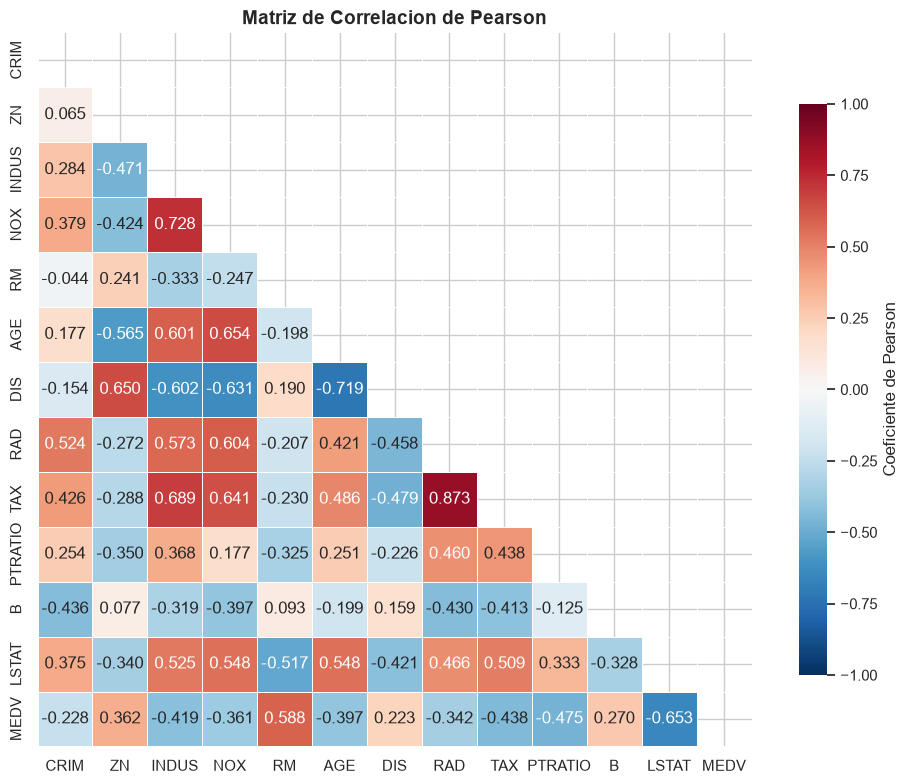

In [53]:
corr_pearson = df[cols_numericas].corr(method='pearson')

# Mascara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

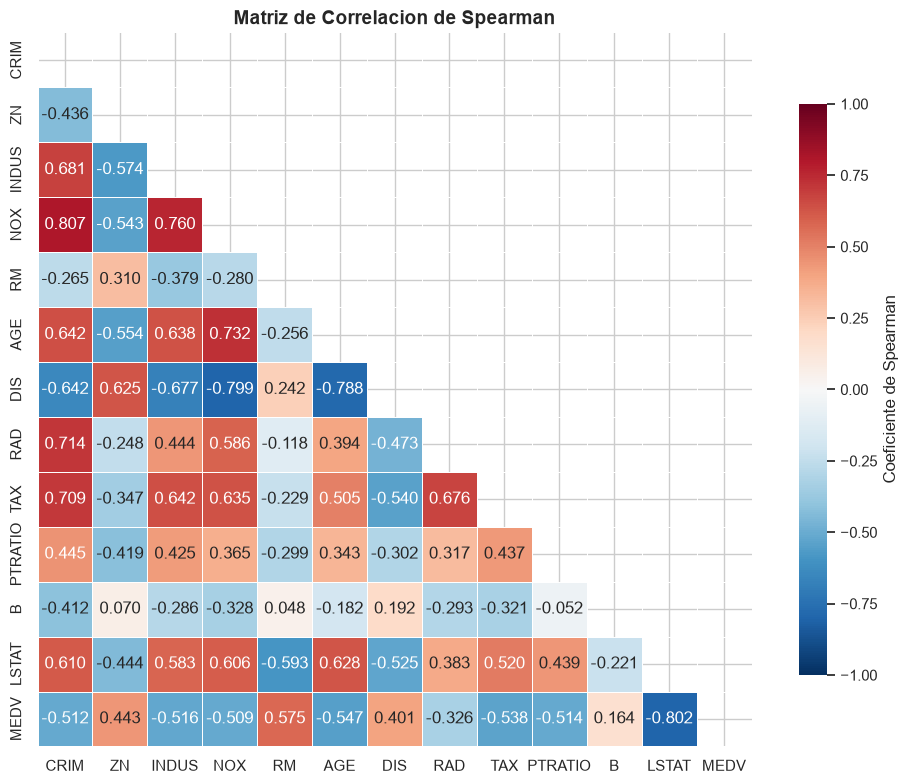

In [54]:
corr_spearman = df[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  RAD <-> TAX: r = 0.8731

Se detectaron 1 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


In [56]:
df[cols_numericas].info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   NOX      532 non-null    float64
 4   RM       535 non-null    float64
 5   AGE      532 non-null    float64
 6   DIS      541 non-null    float64
 7   RAD      528 non-null    float64
 8   TAX      538 non-null    float64
 9   PTRATIO  528 non-null    float64
 10  B        534 non-null    float64
 11  LSTAT    534 non-null    float64
 12  MEDV     535 non-null    float64
dtypes: float64(13)
memory usage: 56.6 KB


In [57]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

       TAX: VIF =       9.12  << MODERADA
       RAD: VIF =       7.76  << MODERADA
       NOX: VIF =       4.57
       DIS: VIF =       4.39
     INDUS: VIF =       3.95
      MEDV: VIF =       3.78
     LSTAT: VIF =       3.58
       AGE: VIF =       3.09
        ZN: VIF =       2.35
        RM: VIF =       2.26
   PTRATIO: VIF =       1.99
      CRIM: VIF =       1.83
         B: VIF =       1.38


In [ ]:
# Seleccion de variables mas relevantes para visualizacion
vars_pairplot = ['TAX', 'INDUS', 'LSTAT', 'AGE', 'RM', 'PTRATIO', 'MEDV']

g = sns.pairplot(df[vars_pairplot + ['CHAS']].dropna().sample(100, random_state=42),
                 hue='CHAS', palette='viridis',
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kws={'alpha': 0.6})
g.figure.suptitle('Pairplot: Variables Clave coloreadas por CHAS',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

---

## 8. Deteccion y Tratamiento de Outliers

### 8.1 Metodo IQR (Rango Intercuartilico)

El metodo IQR es un enfoque no parametrico para detectar outliers. Se basa en los cuartiles de la distribucion:

$$IQR = Q_3 - Q_1$$

Los limites para considerar un valor como outlier son:

$$\text{Limite inferior} = Q_1 - 1.5 \times IQR$$
$$\text{Limite superior} = Q_3 + 1.5 \times IQR$$

El factor 1.5 fue propuesto por Tukey (1977). Para outliers **extremos**, se usa un factor de 3.

**Ventajas:** No asume normalidad; basado en la distribucion real de los datos.

### 8.2 Metodo Z-Score

El Z-score estandariza cada observacion respecto a la media y desviacion estandar:

$$z_i = \frac{x_i - \bar{x}}{s}$$

Se considera outlier cuando $|z_i| > 3$ (bajo normalidad, esto corresponde al 0.27% de los datos).

**Limitacion:** Asume distribucion aproximadamente normal. En distribuciones muy sesgadas, la media y la desviacion estandar pueden estar influenciadas por los propios outliers, generando un efecto de enmascaramiento.

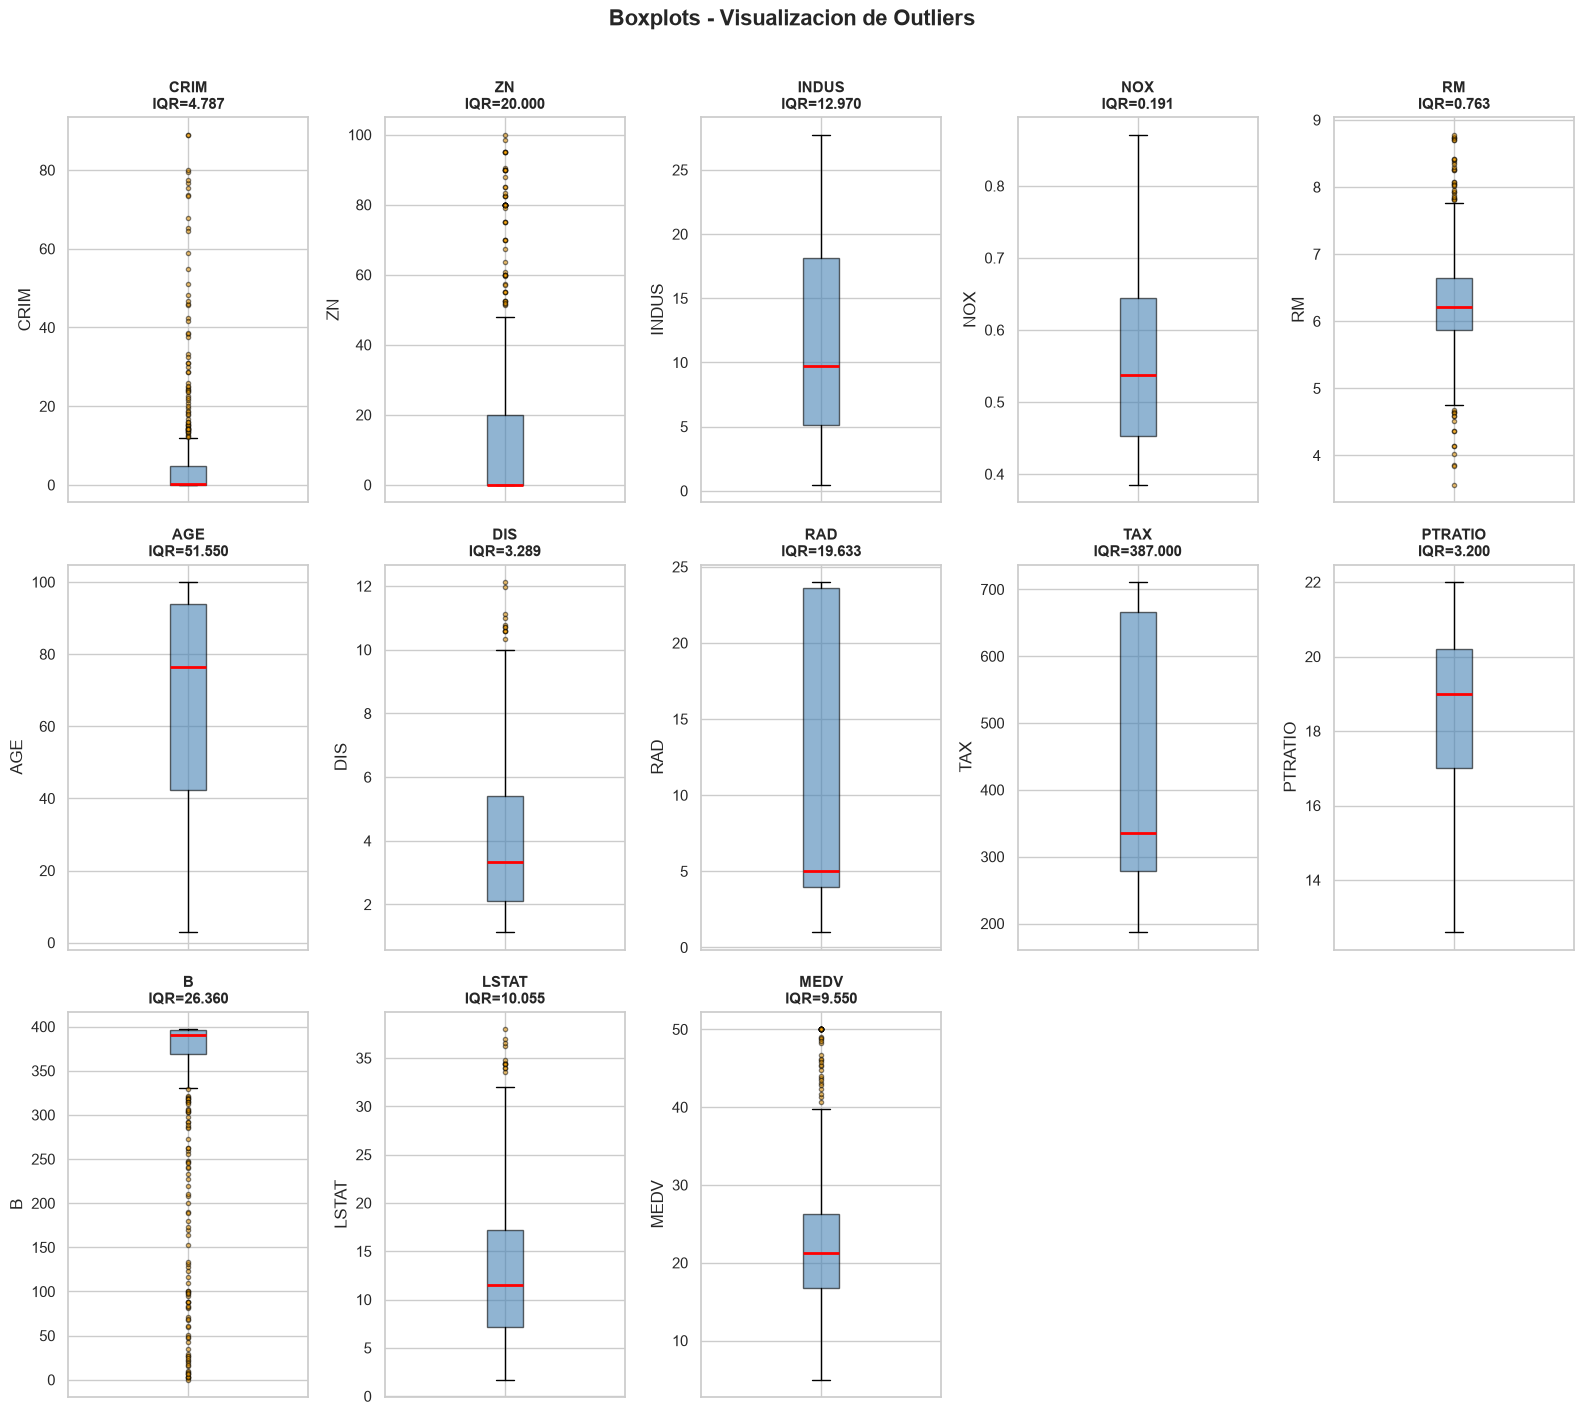

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
Z_THRESHOLD = 3.0
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    # Metodo Z-Score
    z_scores = np.abs(stats.zscore(datos))
    outliers_zscore = (z_scores > Z_THRESHOLD).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
        'Outliers_ZScore': outliers_zscore,
        'Pct_ZScore(%)': outliers_zscore / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR vs Z-Score')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)', 'Outliers_ZScore', 'Pct_ZScore(%)']]

Reporte de Outliers: Metodo IQR vs Z-Score


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%),Outliers_ZScore,Pct_ZScore(%)
0,CRIM,533,4.7869,-7.0959,12.0518,69,12.9456,16,3.0019
1,ZN,534,20.0000,-30.0000,50.0000,60,11.2360,13,2.4345
2,INDUS,541,12.9700,-14.3250,37.5550,0,0.0000,0,0.0000
3,NOX,532,0.1910,0.1665,0.9305,0,0.0000,0,0.0000
4,RM,535,0.7630,4.7310,7.7830,45,8.4112,9,1.6822
5,AGE,532,51.5500,-35.0500,171.1500,0,0.0000,0,0.0000
6,DIS,541,3.2886,-2.8208,10.3336,11,2.0333,7,1.2939
7,RAD,528,19.6327,-25.4490,53.0817,0,0.0000,0,0.0000
8,TAX,538,387.0000,-301.5000,1246.5000,0,0.0000,0,0.0000
9,PTRATIO,528,3.2000,12.2000,25.0000,0,0.0000,0,0.0000


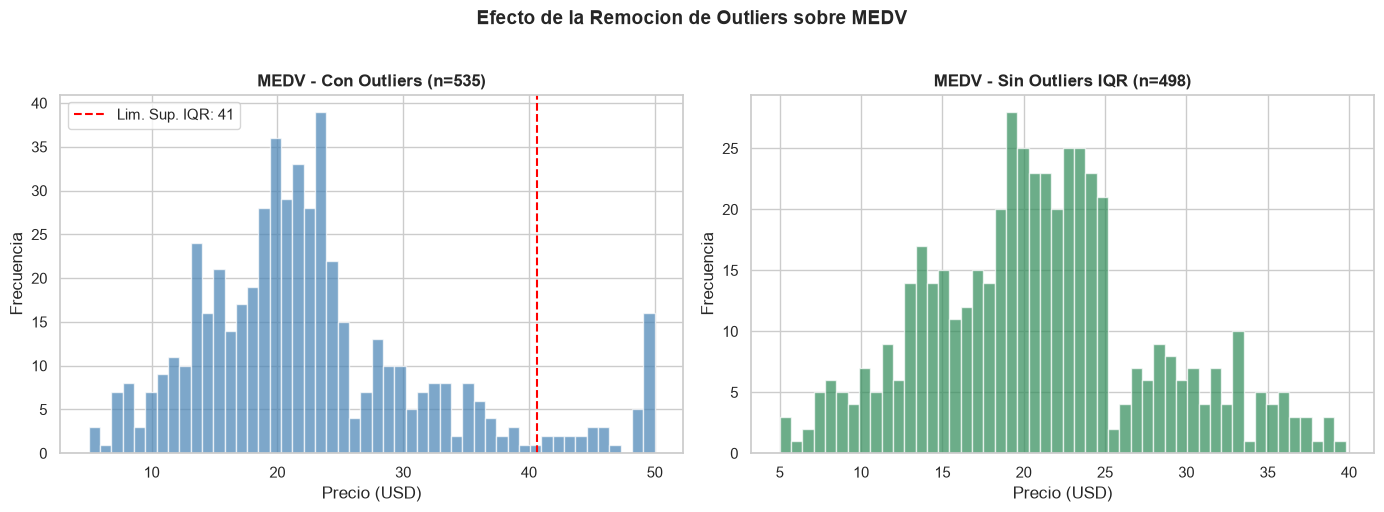

Registros eliminados: 37 (6.92%)


In [ ]:
col_ejemplo = 'MEDV'
datos = df[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remocion de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

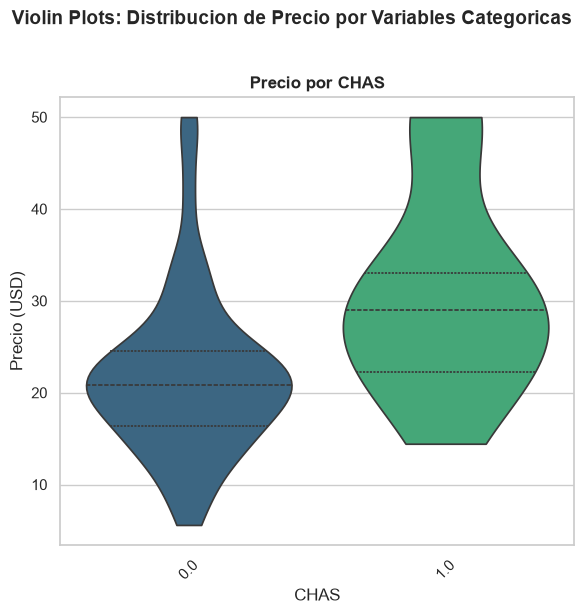

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

for i, cat_col in enumerate(cols_categoricas):
    ax = axes
    # Muestra para eficiencia en la visualizacion
    sample = df[[cat_col, 'MEDV']].dropna().sample(200, random_state=42)
    sns.violinplot(data=sample, x=cat_col, y='MEDV', ax=ax,
                   palette='viridis', inner='quartile', cut=0)
    ax.set_title(f'Precio por {cat_col}', fontweight='bold')
    ax.set_xlabel(cat_col)
    ax.set_ylabel('Precio (USD)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Violin Plots: Distribucion de Precio por Variables Categoricas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 9. Estandarizacion de Variables Numericas

### 9.1 Fundamento Teorico

La **estandarizacion** (o normalizacion Z) transforma cada variable para que tenga media 0 y desviacion estandar 1:

$$z(x) = \frac{x - \mu}{\sigma}$$

**Por que es necesaria:**

- Algoritmos basados en distancias (KNN, SVM, K-Means) son sensibles a la escala de las variables.
- Sin estandarizar, una variable como `price` (rango: 326--18.823) dominaria sobre `depth` (rango: ~43--79) simplemente por su magnitud.
- Garantiza que todas las features contribuyan equitativamente al aprendizaje.

**Alternativa:** La normalizacion Min-Max escala al rango $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Es preferible cuando se necesita preservar la relacion con cero o cuando la distribucion no es aproximadamente normal.

In [ ]:
scaler = StandardScaler()

# Trabajar sobre copia sin nulos
df_num_clean = df[cols_numericas].dropna()

df_estandarizado = pd.DataFrame(
    scaler.fit_transform(df_num_clean),
    columns=cols_numericas,
    index=df_num_clean.index
)

print('Verificacion post-estandarizacion:')
print('=' * 50)
verificacion = pd.DataFrame({
    'Media': df_estandarizado.mean(),
    'Std': df_estandarizado.std(),
    'Min': df_estandarizado.min(),
    'Max': df_estandarizado.max()
})
print(verificacion)
print()
print('Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.')

Verificacion post-estandarizacion:
          Media    Std     Min    Max
CRIM    -0.0000 1.0010 -0.4198 9.9339
ZN       0.0000 1.0010 -0.4877 3.8042
INDUS    0.0000 1.0010 -1.5578 2.4226
NOX     -0.0000 1.0010 -1.4659 2.7323
RM      -0.0000 1.0010 -3.8802 3.5550
AGE      0.0000 1.0010 -2.3354 1.1175
DIS     -0.0000 1.0010 -1.2671 3.9605
RAD      0.0000 1.0010 -0.9828 1.6612
TAX      0.0000 1.0010 -1.3140 1.7982
PTRATIO  0.0000 1.0010 -2.7074 1.6388
B       -0.0000 1.0010 -3.9072 0.4411
LSTAT   -0.0000 1.0010 -1.5311 3.5488
MEDV     0.0000 1.0010 -1.9082 2.9895

Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.


In [ ]:
df_estandarizado

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.4122,-0.4877,-0.9698,-0.9130,-0.2331,-0.4187,-0.0226,-0.7529,-0.9576,0.0206,0.4219,-0.5906,-0.0362
1,-0.4109,-0.4877,0.4061,-1.0167,-0.2246,-1.7842,0.8118,-0.6380,-0.7082,-1.1353,0.4411,-0.5709,0.1488
2,-0.4056,0.0488,-0.7393,-1.2586,-0.5693,-1.2651,1.2849,-0.6380,-0.3756,0.2055,0.4411,-0.5415,-0.1777
3,-0.4102,0.4136,-0.8020,-0.9994,-0.4582,-0.8134,1.4355,-0.6380,-0.9814,-0.7655,0.4264,0.1117,-0.3083
4,-0.4072,-0.4877,-0.3760,-0.2997,0.7072,0.0969,-0.4463,-0.5230,-0.1440,1.1302,0.4266,-0.6985,0.4318
...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,-0.4104,1.4437,-1.1230,-1.0167,1.2727,-1.5033,1.2763,-0.5230,-0.0608,-1.5052,0.3708,-1.3713,1.5093
551,-0.4109,0.7999,-0.9056,-1.0944,0.2798,-1.7807,1.1384,-0.4080,-0.6429,-0.8579,0.2493,-0.8821,0.1270
552,-0.3652,-0.4877,-0.1805,-0.0924,-0.2445,-0.3476,0.0983,-0.6380,-0.6191,-0.0257,0.4337,0.0108,-0.1668
553,-0.3914,-0.4877,1.5690,0.5987,-0.6092,1.0535,-1.0108,-0.6380,0.1708,1.2689,0.3878,1.2149,-1.0049


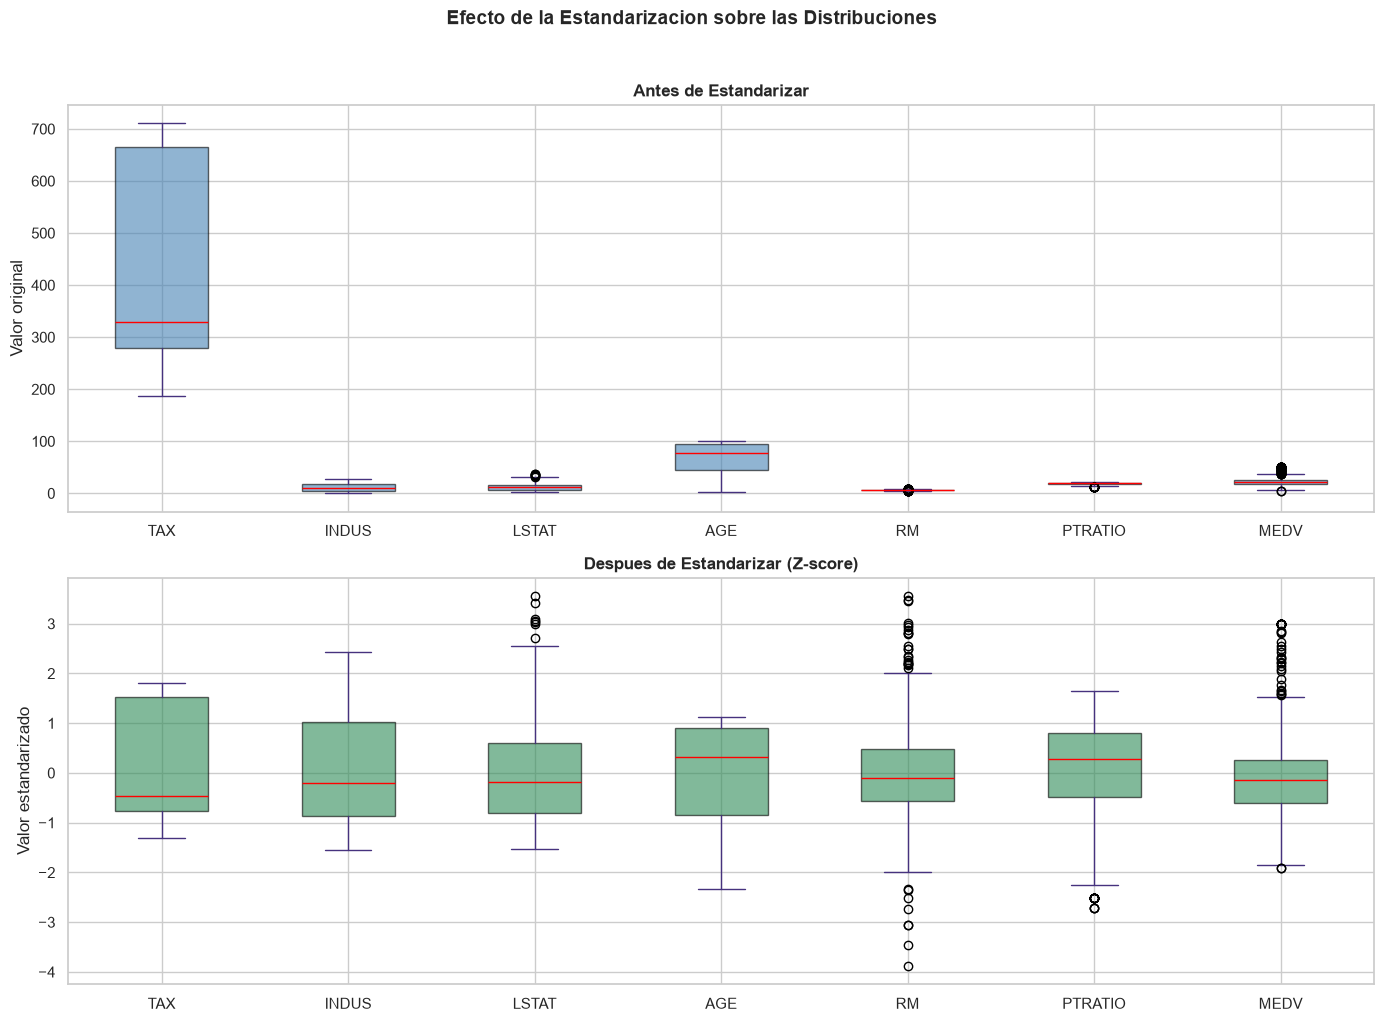

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Antes ['TAX', 'INDUS', 'LSTAT', 'AGE', 'RM', 'PTRATIO', 'MEDV']
df_num_clean[['TAX', 'INDUS', 'LSTAT', 'AGE', 'RM', 'PTRATIO', 'MEDV']].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')

# Despues
df_estandarizado[['TAX', 'INDUS', 'LSTAT', 'AGE', 'RM', 'PTRATIO', 'MEDV']].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Estandarizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')

plt.suptitle('Efecto de la Estandarizacion sobre las Distribuciones',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

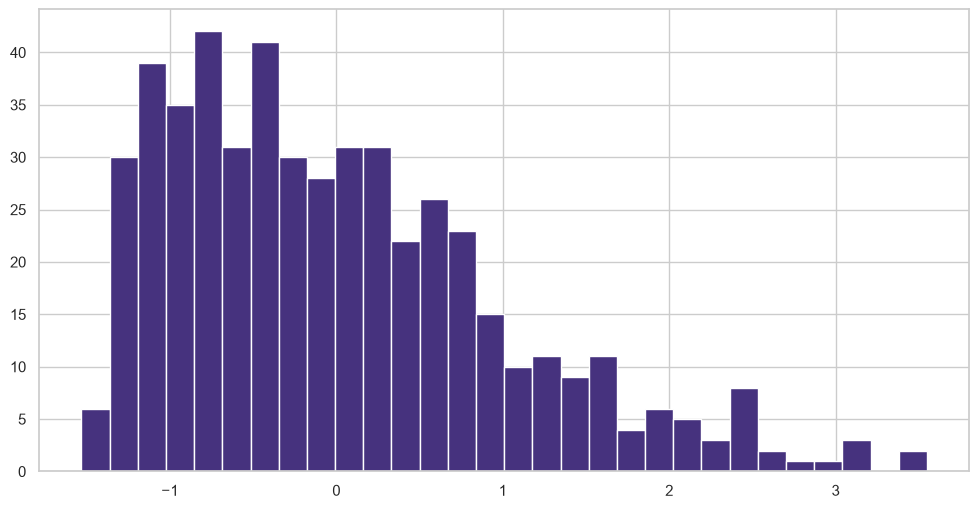

In [ ]:
plt.hist(df_estandarizado["LSTAT"], bins=30);

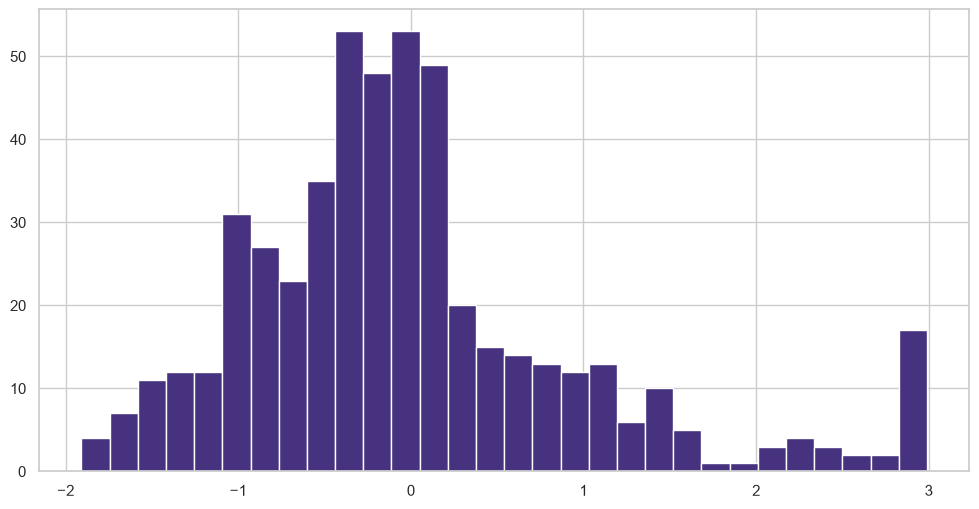

In [ ]:
plt.hist(df_estandarizado["MEDV"], bins=30);

---

## 10. Conclusiones y Proximos Pasos

### Hallazgos principales del EDA <-------Revisar>

1. **Estructura del dataset:** 53.940 registros con 7 variables numericas y 3 categoricas ordinales. Se detectaron registros con dimensiones fisicas nulas (x, y, z = 0) que fueron tratados como inconsistencias.

2. **Distribuciones:** La variable `price` presenta un sesgo positivo pronunciado (cola derecha larga), lo cual sugiere considerar una transformacion logaritmica para modelado. Las variables dimensionales (`x`, `y`, `z`) y `carat` tambien muestran sesgo positivo.

3. **Normalidad:** Ninguna variable numerica supera los tests de normalidad, lo cual es esperado en datos del mundo real. Esto sugiere utilizar metodos no parametricos o transformaciones previas al modelado.

4. **Correlaciones:** Existe alta colinealidad entre `carat` y las dimensiones fisicas (`x`, `y`, `z`), asi como entre `x`, `y` y `z` entre si. Se recomienda seleccion de features o PCA para reducir redundancia.

5. **Outliers:** Los metodos IQR y Z-score detectan proporciones significativas de outliers en `carat`, `depth`, `table` y `price`. La decision de tratamiento depende del modelo a utilizar.

6. **Balanceo:** La variable `cut` presenta un IR moderado, con la clase `Ideal` representando ~40% de los datos. En un problema de clasificacion multiclase, esto podria sesgar el modelo.

### Proximos pasos

- Feature engineering: transformaciones logaritmicas, encoding ordinal de variables categoricas.
- Seleccion de features: basada en VIF, correlaciones, o importancia de modelo.
- Division train/test estratificada.
- Entrenamiento de modelos baseline (regresion lineal, decision tree, random forest).
- Evaluacion con metricas apropiadas (RMSE, MAE, $R^2$ para regresion; accuracy, F1, AUC para clasificacion).